In [85]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import chess

In [86]:
def show_img(img, title="", cmap=None, figsize=(8, 8)):
    plt.figure(figsize=figsize)
    if len(img.shape) == 2:
        plt.imshow(img, cmap=cmap if cmap else "gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

video_path = Path("videos") / "chess_recording_1.mp4"

cap = cv2.VideoCapture(str(video_path))

ret, first_frame = cap.read()

#show_img(first_frame, "First Frame")

#--

video_path_2 = Path("videos") / "chess_recording_2.mp4"

cap_2 = cv2.VideoCapture(str(video_path_2))

ret_2, first_frame_2 = cap_2.read()

#show_img(first_frame_2, "First Frame Second Video")

#--

video_path_3 = Path("videos") / "chess_recording_3.mp4"

cap_3 = cv2.VideoCapture(str(video_path_3))

ret_3, first_frame_3 = cap_3.read()

#show_img(first_frame_3, "First Frame Third Video")

In [87]:

def crop_search_region(frame):
    #Crop the search region slightly to get rid of top URL bar, side scroll bar, and task bar to avoid detecting them when looking for board
    top=0.06
    bottom=0.04
    left=0.03
    right=0.03

    h, w = frame.shape[:2]

    y1 = int(top * h)
    y2 = int((1 - bottom) * h)
    x1 = int(left * w)
    x2 = int((1 - right) * w)

    cropped = frame[y1:y2, x1:x2]
    offset = {"x": x1, "y": y1}

    return cropped, offset



def line_length(line):
    #Get the length of a hough line in the image
    x1, y1, x2, y2 = line
    return np.hypot(x2 - x1, y2 - y1)



def line_angle_deg(line):
    #Get the degree of a hough line in the image, -180 to 180 degrees
    x1, y1, x2, y2 = line
    return np.degrees(np.arctan2(y2 - y1, x2 - x1))



def get_hough_segments(img):
    #Get the Hough line segments in an image
    #Returns the hough lines that are long enough to potentially be chess board lines

    #Grayscale, blur and get canny edges
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    #Get the height and width of the image
    h, w = img.shape[:2]

    #Get the Hough Lines of the
    #HoughLinesP is used because it can return the direct end points of the lines 
    # We want to analyze the endpoints of the lines and see if they are likely chess board grid lines 
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi / 180, threshold=70, minLineLength=min(h, w) // 5, maxLineGap=25)
    #Tuning threshold, minLinelength, and maxLineLength is what changes the ability to detect board lines
    # They have been tested and set to these values currently (threshold=70, minLineLength=min(h, w) // 5, maxLineGap=25) which yields good results

    #Keep chess likely chess board lines
    segments = []

    #Board lines should span a good portion of the image, so we only keep sufficently long lines
    for line in lines:
        x1, y1, x2, y2 = line[0]
        seg = (x1, y1, x2, y2)

        #Only keep lines that are greater than 0.4 of the smallest size dimension
        if line_length(seg) > min(h, w) * 0.4:
            segments.append(seg)
        

    line_img = img.copy()
    for x1, y1, x2, y2 in segments:
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    #Look at Edge images and Hough Lines
    #show_img(edges, "Candidate Edges")
    #show_img(line_img, "Candidate Hough Lines")
        
    #Return the likely chess board lines
    return segments



def split_line_families(segments):
    #Splits a list of lines into horizontal and vertical lines
    #Chess board grid lines are either a horizontal row line or they are a vertical column line
    #Returns the 2 seperate lists, a list of the vertical lines and a list of the horizontal lines

    #Row and column lines
    row_lines = []
    col_lines = []

    for seg in segments:

        #Get the angle of the line in degrees
        angle = line_angle_deg(seg)

        #Correct degrees so that they range from -90 to 90
        if angle < -90:
            angle += 180
        if angle > 90:
            angle -= 180

        #If the line is more flat than tall it is classified as a horizontal row line
        #Otherwise it is defaulted to a vertical gridline to help account for the slight tilt in angle of the 3D board perspective
        if abs(angle) < 35:
            row_lines.append(seg)
        else:
            col_lines.append(seg)

    #Return the rows and columns
    return row_lines, col_lines



def filter_by_dominant_angle(lines, max_deviation):
    #Takes a list of lines and a mximum deviation in degrees and filters out the lines that lie outside maximum deviation

    angles = []

    #Iterate through the lines and normalize the angles
    for line in lines:
        angle = line_angle_deg(line)

        if angle < -90:
            angle += 180
        if angle > 90:
            angle -= 180

        angles.append(angle)

    #Get the median angle from the angles
    median_angle = np.median(angles)

    filtered = []

    #iterate through the lines and angles
    for i in range(len(lines)):
        line = lines[i]
        angle = angles[i]

        #If the angle of this line is within the maximum devition of the maximum then keep it
        if abs(angle - median_angle) <= max_deviation:
            filtered.append(line)

    return filtered


def cluster_lines_by_position(lines, orientation="row", cluster_dist=18):
    #Takes all the lines in a given direction, an orientation, and a cluster distance
    #Gets the average position of the line in the image, sorts all the lines based on position, 
    # Clusters the lines based on position, the size of each cluster aand the number of clusters are indirectly determined by the cluster_dist
    # cluster_dist represents the maximum range a line can be from the cluster mean to be classified as in cluster.

    if len(lines) == 0:
        return []

    #Gets the lines and their position
    positioned = []

    #Get an average dimension in dimesnion opposite to line direction
    #Essentially at what y-value is the horizontal line or what x-value is the vertical line positioned at
    for seg in lines:
        x1, y1, x2, y2 = seg

        #Get the average y-value of rows and the average x-value of columns
        if orientation == "row":
            pos = (y1 + y2) / 2
        else:
            pos = (x1 + x2) / 2

        positioned.append((pos, seg))
        #Append the line with its position

    #Sort all the lines based on position from smallest to biggest
    positioned.sort(key=lambda t: t[0])

    #Define a new set of lines that are clustered close together
    clusters = []
    current = [positioned[0]]
    #Start the current value at the first line

    #Skip the first line as it is already set to current and iterate through all other lines
    for item in positioned[1:]:
        #Get the current mean of the line cluster center
        current_mean = np.mean([pos for pos, _ in current])

        #If the distance between the current line position and the current cluster mean 
        # is less than the defined cluster distance add this line to the current cluster.
        # If the distance between the line position and current mean falls outside the cluster distance range 
        # start a new cluster, adnd add this line and its position to it
        if abs(item[0] - current_mean) < cluster_dist:
            current.append(item)
        else:
            clusters.append(current)
            current = [item]

    #Append the final cluster that didn't get appended in the loop
    clusters.append(current)

    #merge the clusters into one best line
    merged = []

    #Iterate through the clusters and get the best line from each cluster
    for cluster in clusters:
        #Get a list of the line segments in each cluster
        segs = [seg for _, seg in cluster]

        #The best line is the longest, so get the line with the maximum line length
        best = max(segs, key=line_length)

        #Add only the best (longest) line from the cluster
        merged.append(best)

    #Return the only the longest lines from each segment
    return merged


def contour_candidates(search_frame):
    #Gets all the contours in an image, and returns the contours that could contain a chess boad
    #Checks if the area of the contour is in a sufficent range
    #Checks the aspect ratio of the contour to ensure that it falls into an acceptable chess board range

    #Define the maximum and minimum area that a contour can be while still likely being a chess board
    min_area_ratio=0.03
    max_area_ratio=1.0

    #grayscale, blur, canny
    gray = cv2.cvtColor(search_frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    edges = cv2.Canny(blur, 50, 150)

    #After the canny edge detection the gridlines of the board sometimes don't always connect
    #To account for this we try to close any gridlines that are not connecting
    kernel = np.ones((7, 7), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    #closed is the closed canny edges of the region which makes for better results when looking for board lines

    #Look at the contours of the closed region
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    #Get the frame area in pixels
    h, w = search_frame.shape[:2]
    frame_area = h * w

    #Keep only the contours that are candidates to be chess boards
    candidates = []

    #Check all the contours and keep only board candidates
    for cnt in contours:

        #Contour area
        area = cv2.contourArea(cnt)

        #Check if the contour area is within acceptable raange
        if area < min_area_ratio * frame_area:
            continue
        if area > max_area_ratio * frame_area:
            continue

        #Get the dimensions of the contour
        x, y, bw, bh = cv2.boundingRect(cnt)

        
        if bw <= 0 or bh <= 0:
            continue
        
        #Get the aspect ratio of the contour
        aspect = bw / bh

        #Skip if aspecct ratio is outside of acceptable range
        if aspect < 0.45 or aspect > 2.0:
            continue

        #If passed all checks append contour as a candidate
        candidates.append({
            "contour": cnt,
            "x": x,
            "y": y,
            "w": bw,
            "h": bh,
            "area": area,
            "aspect": aspect
        })

    return candidates, edges, closed



def score_candidate_grid(search_frame, cand):
    #Takes a frame and a candidate board contour and scores how chess-boardy the candidate is with respect to the frame

    #Get the dimensions of the candidate board contour
    x, y, w, h = cand["x"], cand["y"], cand["w"], cand["h"]

    # Add some temporary padding while scoring
    pad_x = int(0.08 * w)
    pad_y = int(0.08 * h)

    #Get the dimensions of the frame
    s_h, s_w = search_frame.shape[:2]

    #account for the padding
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(s_w, x + w + pad_x)
    y2 = min(s_h, y + h + pad_y)

    #Crop the search frame to the contour region
    crop = search_frame[y1:y2, x1:x2]

    #Get all the lines in the contour 
    segments = get_hough_segments(crop)

    #Split the lines into row and column lines
    row_lines, col_lines = split_line_families(segments)

    #Filter the lines in each direction by dominant angle
    row_lines = filter_by_dominant_angle(row_lines, max_deviation=8)
    col_lines = filter_by_dominant_angle(col_lines, max_deviation=8)

    #Cluster both the row lines and the column lines based on position
    row_lines = cluster_lines_by_position(row_lines, "row", cluster_dist=18)
    col_lines = cluster_lines_by_position(col_lines, "col", cluster_dist=18)

    row_lines = sorted(row_lines, key=line_length, reverse=True)[:9]
    col_lines = sorted(col_lines, key=line_length, reverse=True)[:9]

    row_lines = sorted(row_lines, key=lambda l: (l[1] + l[3]) / 2)
    col_lines = sorted(col_lines, key=lambda l: (l[0] + l[2]) / 2)

    #Get the number of lines in each row and column
    row_count = len(row_lines)
    col_count = len(col_lines)
    #Dependent on the candidate and the defined cluster_dist but ideally somewhere between 5-15

    #Chessboard like candidates should have a sufficent number of rows and columns
    # If this number is small that means this candidate is not very board like with respect to line count
    grid_score = min(row_count, 10) * min(col_count, 10)
    #Between 0 to 100

    # Get the aspect ratio of the candidate
    aspect = cand["aspect"]
    #between 0.45 to 2.0

    #Define an aspect penalty, the aspect region should be mostly squareish (aspect=1) but the 3D board is slightly warped
    # so an aspect penalty slightly larger than 1 is defined to help account for this
    # If this number is small then this is a board like candidate, if it is large then it is not a board like candidate
    aspect_penalty = -abs(aspect - 1.1)
    #between -0.9 to 0

    # Get the ratio of the candidate area to the search frame area
    area_score = cand["area"] / (search_frame.shape[0] * search_frame.shape[1])
    #between 0 and 1 but not including 0 and 1

    #Define a score for how chessboard like the candidate is
    score = (
        20 * grid_score +
        3 * row_count +
        3 * col_count +
        100 * area_score +
        20 * aspect_penalty
    )
    #These values have been tested to give stable and consistent results in most cases but can still fail

    #Return the score
    return score



def find_best_contour_grid_candidate(search_frame):
    candidates, edges, closed = contour_candidates(search_frame)

    #Useful Debug stuff
    """
    show_img(edges, "Search Region Edges")
    show_img(closed, "Closed Edges")
    """

    cand_img = search_frame.copy()
    for cand in candidates:
        x, y, w, h = cand["x"], cand["y"], cand["w"], cand["h"]
        cv2.rectangle(cand_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        #show_img(cand_img, f"Contour Candidates: {len(candidates)}")
    

    #start with no best
    best = None
    best_score = -np.inf

    #Iterate through all the candidates, score them, if the score is better then the current best keep that candidate instead
    for cand in candidates:
        score = score_candidate_grid(search_frame, cand)

        if score > best_score:
            best_score = score
            best = cand

    return best, candidates



def expand_box(box, frame_shape):
    #Slightly expand the window frame to account for 3D board

    #Padding values
    pad_left=0.0
    pad_right=0.0
    pad_top=0.13
    pad_bottom=0.0

    s_h, s_w = frame_shape[:2]

    x, y, w, h = box["x"], box["y"], box["w"], box["h"]

    x1 = max(0, x - int(pad_left * w))
    y1 = max(0, y - int(pad_top * h))
    x2 = min(s_w, x + w + int(pad_right * w))
    y2 = min(s_h, y + h + int(pad_bottom * h))

    return {
        "x": x1,
        "y": y1,
        "w": x2 - x1,
        "h": y2 - y1
    }


def crop_from_box(frame, box):
    #Takes the fraame and the final crop box and crops the frame
    x, y, w, h = box["x"], box["y"], box["w"], box["h"]
    return frame[y:y+h, x:x+w]



def detect_board_contour_grid(frame, title_prefix=""):
    #Takes a frame and crops the frame to contain only the chess board
    
    #slightly crop the search region
    search_frame, offset = crop_search_region(frame)

    #show_img(search_frame, f"{title_prefix} Search Region")

    #Get the most board like contour in the image
    best, candidates = find_best_contour_grid_candidate(search_frame)

    if best is None:
        #Hopefully don't ever see this
        print("No board found.")
        return None

    # Use the best candidate to create a game window
    proposal_box = best

    # Get the coordinates of the proposal box in the full frame
    full_box = {
        "x": proposal_box["x"] + offset["x"],
        "y": proposal_box["y"] + offset["y"],
        "w": proposal_box["w"],
        "h": proposal_box["h"]
    }

    #Slightly expand the cropped window to better account for the 3D board
    final_box = expand_box(full_box, frame.shape,)

    #Crop to the final window
    final_crop = crop_from_box(frame, final_box)

    
    result_img = frame.copy()
    x, y, w, h = final_box["x"], final_box["y"], final_box["w"], final_box["h"]
    cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
    #show_img(result_img, f"{title_prefix} Final Board Box")
    show_img(final_crop, f"{title_prefix} Final Board Crop")
    
    
   
    return {
        "search_frame": search_frame,
        "offset": offset,
        "candidates": candidates,
        "best_candidate": best,
        "final_box": final_box,
        "board_crop": final_crop
    }

In [88]:
#result_1 = detect_board_contour_grid(first_frame, "Board 1")
#result_2 = detect_board_contour_grid(first_frame_2, "Board 2")
#result_3 = detect_board_contour_grid(first_frame_3, "Board 3")

#board_crop_1 = result_1["board_crop"]
#board_crop_2 = result_2["board_crop"]
#board_crop_3 = result_3["board_crop"]

In [89]:
def order_points(pts):
    #Given a set of points, find the top left, top right, bottom left, and bottom right point and return it as an array

    pts = np.array(pts, dtype="float32")

    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)

    top_left = pts[np.argmin(s)]
    bottom_right = pts[np.argmax(s)]
    top_right = pts[np.argmin(diff)]
    bottom_left = pts[np.argmax(diff)]

    return np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")


def find_outer_board_corners(board_crop):

    #Graycale, blur, canny
    gray = cv2.cvtColor(board_crop, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 40, 120)

    #Close the edges
    kernel = np.ones((7, 7), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    #Get the contours of the board frame
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


    if len(contours) == 0:
        return None

    #Get the frame dimensions and define the minimum area of a board as 30% of the frame
    h, w = board_crop.shape[:2]
    min_area = 0.30 * h * w

    #Sort the contours from largest to smallest
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    #Iterate through the contours on the screen from largest to smallest
    for cnt in contours:

        #Check the area of the contour
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        #Get the perimeter of the contour
        peri = cv2.arcLength(cnt, True)

        #3D Board is slighlty trapezoidal so define varying epsilon values to be used when approximating the contour as a square
        epsilons = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07]

        #Iterate through all the epsilon values
        for eps in epsilons:

            #Approximate the shape of the contour 
            approx = cv2.approxPolyDP(cnt, eps * peri, True)

            #Return the corner points for the largest closed square contour in the frame
            if len(approx) == 4:
                corners = approx.reshape(4, 2)
                return order_points(corners)

    return None


def remove_padding_2d(board_crop, pad_top=0.13):
    #Undoes the top padding on the 2D boards as padding is only needed for the 3D board
    h, w = board_crop.shape[:2]

    y1 = int(pad_top * h)
    y2 = h

    return board_crop[y1:y2, :]

def warp_board_from_outer_corners(board_crop, output_size=800, margin=70):
    #Takes a board cropped framr, a square output size, and a margin and computes and applies a homography to correct the perspective of the board
    #Detects the 4 outer corners of the board 
    corners = find_outer_board_corners(board_crop)

    if corners is None:
        return None, None

    dst = np.array([
        [margin, margin],
        [output_size - 1 - margin, margin],
        [output_size - 1 - margin, output_size - 1 - margin],
        [margin, output_size - 1 - margin]
    ], dtype="float32")

    H = cv2.getPerspectiveTransform(corners, dst)
    warped = cv2.warpPerspective(board_crop, H, (output_size, output_size))

    return warped, H


def is_roughly_2d_board(board_crop):
    #Takes a board and detects if it is a 2D/square board if it is within a certain aspect ratio
    #If it is detected as square it does not apply a homography
    h, w = board_crop.shape[:2]
    aspect = w / h

    return 0.8 <= aspect <= 1.2


def prepare_board_image(board_crop, output_size=800):
    #Takes the cropped board frame with an output size and prepares it by computing a homography if needed, setting the board to an outut size, and accounts for padding on the border

    #If the board is 2D, undo the padding and warp the square output size
    if is_roughly_2d_board(board_crop):
        trimmed = remove_padding_2d(board_crop, pad_top=0.13)
        board_ready = cv2.resize(trimmed, (output_size, output_size))
        return board_ready, None

    #Compute the homography from the detected outer corners
    warped_board, H = warp_board_from_outer_corners(
        board_crop,
        output_size=output_size,
        margin=70
    )

    if warped_board is None:
        print("3D corner warp failed, using resized crop instead.")
        board_ready = cv2.resize(board_crop, (output_size, output_size))
        return board_ready, None

    return warped_board, H

In [90]:
#frames = [first_frame, first_frame_2, first_frame_3]
"""
for i in range(len(frames)):
    result = detect_board_contour_grid(frames[i], f"Board {i+1}")

    if result is None:
        print(f"Board {i+1}: detection failed")
        continue

    board_crop = result["board_crop"]

    board_ready, H = prepare_board_image(board_crop, output_size=800)

    show_img(board_ready, f"Prepared Board {i+1}")

"""

'\nfor i in range(len(frames)):\n    result = detect_board_contour_grid(frames[i], f"Board {i+1}")\n\n    if result is None:\n        print(f"Board {i+1}: detection failed")\n        continue\n\n    board_crop = result["board_crop"]\n\n    board_ready, H = prepare_board_image(board_crop, output_size=800)\n\n    show_img(board_ready, f"Prepared Board {i+1}")\n\n'

In [ ]:


def get_square_name(row, col, flipped=False):
    #Get the name of a square, rank and file

    if not flipped:
        files = "abcdefgh"
        ranks = "87654321"
        return files[col] + ranks[row]
    else:
        files = "hgfedcba"
        ranks = "12345678"
        return files[col] + ranks[row]




def infer_orientation_from_first_white_move(prev_board, curr_board, board_size=800):
    #Takes the first move of the game, If the move was detected on the bottom half of the board then the player is white
    #If the change was on the top half of the board then the player is black and the orientation of the detected squares and moves can be accounted for


    cell = board_size // 8

    raw_scores = []

    prev_gray = cv2.cvtColor(prev_board, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(curr_board, cv2.COLOR_BGR2GRAY)

    for r in range(8):
        for c in range(8):
            y1, y2 = r * cell, (r + 1) * cell
            x1, x2 = c * cell, (c + 1) * cell

            diff = cv2.absdiff(
                prev_gray[y1:y2, x1:x2],
                curr_gray[y1:y2, x1:x2]
            )

            inner = diff[15:-15, 15:-15]
            raw_scores.append((r, c, np.mean(inner)))

    
    raw_scores.sort(key=lambda x: x[2], reverse=True)

    changed_phys = raw_scores[:2]
    avg_row = np.mean([r for r, c, s in changed_phys])

    
    flipped = avg_row < 4

    return flipped, changed_phys, raw_scores



def board_frame_difference(prev_board, curr_board):
    #Takes the previous board frame and the current board frame and computes the difference between them

    prev_gray = cv2.cvtColor(prev_board, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(curr_board, cv2.COLOR_BGR2GRAY)

    diff = cv2.absdiff(prev_gray, curr_gray)
    score = np.mean(diff)

    return score, diff


def square_difference_scores(prev_board, curr_board, board_size=800, flipped=False):
    #Takes the current board frame and the previous board frame and splits the frame into 8x8 squares and gets the difference in each square

    cell_size = board_size // 8
    scores = {}

    prev_gray = cv2.cvtColor(prev_board, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(curr_board, cv2.COLOR_BGR2GRAY)

    #Iterate through all the squares on the board
    for r in range(8):
        for c in range(8):
            #Get square positions
            y1 = r * cell_size
            y2 = (r + 1) * cell_size
            x1 = c * cell_size
            x2 = (c + 1) * cell_size

            #Get the square in both the current and previous frame
            prev_cell = prev_gray[y1:y2, x1:x2]
            curr_cell = curr_gray[y1:y2, x1:x2]

            #Find the difference in this square
            diff = cv2.absdiff(prev_cell, curr_cell)

            #Ignore borders of square slightly because board grid can cause noise on some board themes
            inner = diff[15:-15, 15:-15]

            scores[get_square_name(r, c, flipped)] = np.mean(inner)

    return scores


def infer_move_from_changed_squares(prev_board, curr_board, board_size=800, square_thresh=12, flipped=False):
    #Takes the previous and current board between which a move was made. Finds all the squares who have a change greater than some threshold. 
    #Returns the 2 most changed squares and the squares likely to have had a piece move in it

    #Get the scores of all the squares
    scores = square_difference_scores(prev_board, curr_board, board_size, flipped=flipped)

    #Get all the scores that are above a certain threshold
    changed = [
        square for square, score in scores.items()
        if score > square_thresh
    ]

    #Sort the changed squares from most changed to least changes
    changed = sorted(changed, key=lambda sq: scores[sq], reverse=True)

    #If a move occured then there should be at least 2 squares above the change threshold
    if len(changed) < 2:
        return None, changed, scores

    return (changed[0], changed[1]), changed, scores


def square_to_row_col(square, flipped=False):
    #Takes a square and wether the board is flipped and returns the name of the square

    file_char = square[0]
    rank_char = square[1]

    if not flipped:
        files = "abcdefgh"
        ranks = "87654321"
    else:
        files = "hgfedcba"
        ranks = "12345678"

    col = files.index(file_char)
    row = ranks.index(rank_char)

    return row, col

def draw_changed_squares(board_img, changed, board_size=800, flipped=False):
    #Highlight the squares that the move was made in (Highlight the squares thaat changed the most)
    vis = board_img.copy()
    cell_size = board_size // 8

    for square in changed:
        row, col = square_to_row_col(square, flipped=flipped)

        x1 = col * cell_size
        y1 = row * cell_size
        x2 = x1 + cell_size
        y2 = y1 + cell_size

        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 255), 3)
        cv2.putText(vis, square, (x1 + 8, y1 + 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    return vis


def infer_legal_move_from_scores(board, scores):
    #Takes the detected changes in the board and based on the squares with the most change it detects the legal moves on the board.
    #


    candidates = []

    for move in board.legal_moves:
        from_sq = chess.square_name(move.from_square)
        to_sq = chess.square_name(move.to_square)

        score = scores.get(from_sq, 0) + scores.get(to_sq, 0)

        if board.is_castling(move):
            if to_sq == "g1":
                rook_from, rook_to = "h1", "f1"
            elif to_sq == "c1":
                rook_from, rook_to = "a1", "d1"
            elif to_sq == "g8":
                rook_from, rook_to = "h8", "f8"
            else:
                rook_from, rook_to = "a8", "d8"

            score += scores.get(rook_from, 0) + scores.get(rook_to, 0)

        candidates.append((move, score))

    candidates.sort(key=lambda x: x[1], reverse=True)

    best_move, best_score = candidates[0]
    second_score = candidates[1][1] if len(candidates) > 1 else 0

    return best_move, best_score, second_score



def render_simple_chess_board(board, size=800, flipped=False):
    #Takes the moves detected from the video and recreates a simple chess board to be able to ensure that the moves being detected match the moves in the video
    #Very useful for testing and debugging but does not need to be included in the final version

    #Create the image
    img = np.zeros((size, size, 3), dtype=np.uint8)
    cell = size // 8

    #Define color for light and dark squares
    light = (240, 217, 181)
    dark = (181, 136, 99)

    #Symbols to represent piece p=pawn, n=knight, etc.
    piece_symbols = {
        "P": "P", "N": "N", "B": "B", "R": "R", "Q": "Q", "K": "K",
        "p": "p", "n": "n", "b": "b", "r": "r", "q": "q", "k": "k",
    }

    #Color squares in image and place pieces
    for row in range(8):
        for col in range(8):
            color = light if (row + col) % 2 == 0 else dark
            y1 = row * cell
            x1 = col * cell
            cv2.rectangle(img, (x1, y1), (x1 + cell, y1 + cell), color, -1)

            if flipped:
                square = chess.square(7 - col, row)
            else:
                square = chess.square(col, 7 - row)

            piece = board.piece_at(square)

            if piece is not None:
                text = piece_symbols[piece.symbol()]

                text_color = (20, 20, 20) if piece.color == chess.BLACK else (245, 245, 245)
                outline_color = (245, 245, 245) if piece.color == chess.BLACK else (20, 20, 20)

                font = cv2.FONT_HERSHEY_SIMPLEX
                scale = 1.8
                thickness = 4

                (tw, th), _ = cv2.getTextSize(text, font, scale, thickness)
                tx = x1 + (cell - tw) // 2
                ty = y1 + (cell + th) // 2

                cv2.putText(img, text, (tx, ty), font, scale, outline_color, thickness + 3)
                cv2.putText(img, text, (tx, ty), font, scale, text_color, thickness)

    return img

In [92]:
def play_and_track_2d_moves(video_path, output_size=800):
    #Plays a video if it is 2D and tracks the move sequence

    #Open the video and get the first frame
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error opening video")
        return
    ret, first_frame = cap.read()
    if not ret:
        print("Could not read first frame")
        return

    #Detect the board from the first frame
    result = detect_board_contour_grid(first_frame)

    if result is None:
        print("Could not detect board in first frame")
        return

    #Crop to just the board
    final_box = result["final_box"]
    first_crop = result["board_crop"]

    # Prepare first board
    first_ready, H = prepare_board_image(first_crop, output_size)

    if H is not None:
        print("2D Board version only. 3D board is probably going to need its own tracking sequence but can reuse many of these functions")
        return

    #Intialize the stable and previous frame to the first frame
    prev_raw_board = first_ready.copy()
    last_stable_board = first_ready.copy()

    #Start not moving with an empty move list
    moving = False
    move_list = []
    movement_start_board = None

    #Set thresholds for wether the piece is currently moving: moving threshold
    #Sets the thresholds for wether the frame is stable / the pieces are done moving: stable_threshold
    #Sets the theshold for wether a square has had something change inside of it (Piecce moved to or from square): square_change_threshold
    moving_threshold = 0.15
    stable_threshold = 0.05
    square_change_threshold = 10.0

    #Require a frame to be stable for 7 frames to be considered stable
    stable_count = 0
    required_stable_frames = 3
    min_move_score = 14.0

    #Initalize a base chess board
    board = chess.Board()
    flipped = False

    #Iterate through all the frames in the video
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        board_crop = crop_from_box(frame, final_box)

        #In every frame get only the board
        trimmed = remove_padding_2d(board_crop, pad_top=0.13)
        board_ready = cv2.resize(trimmed, (output_size, output_size))

        #Get the difference between frames
        diff_score, diff_img = board_frame_difference(prev_raw_board, board_ready)
        print("diff_score:", diff_score)

        #If the difference between frames is above the moving threshold and it wasn't already moving
        if diff_score > moving_threshold and not moving:
            moving = True #Begin Moving
            stable_count = 0 #Start counting stable frames from 0
            movement_start_board = last_stable_board.copy() #The start of movement was the last stable copy
            print("Piece movement started")

        #If the frames are in movement
        elif moving:

            #If within the stable threshold begin counting the stable frames otherwise if pieces are still moving then set start stable frames from 0
            if diff_score < stable_threshold:
                stable_count += 1
            else:
                stable_count = 0


            #If pieces were moving but now things have been stable for long enough
            if stable_count >= required_stable_frames:

                #Stop moving
                moving = False
                new_stable_board = board_ready.copy()


                if len(move_list) == 0:
                    flipped, changed_phys, raw_scores = infer_orientation_from_first_white_move(
                        movement_start_board,
                        new_stable_board,
                        board_size=output_size
                    )

                    board = chess.Board()
                    board.turn = chess.WHITE

                    scores = square_difference_scores(
                        movement_start_board,
                        new_stable_board,
                        board_size=output_size,
                        flipped=flipped
                    )

                    move, move_score, second_score = infer_legal_move_from_scores(board, scores)
                    score_gap = move_score - second_score

                    changed = [
                        get_square_name(r, c, flipped=flipped)
                        for r, c, s in changed_phys
                    ]

                    if flipped:
                        print("Detected orientation: WHITE ON TOP / BLACK ON BOTTOM")
                    else:
                        print("Detected orientation: BLACK ON TOP / WHITE ON BOTTOM")

                    print("Detected starting turn: WHITE")

                else:
                    move_pair, changed, scores = infer_move_from_changed_squares(
                        movement_start_board,
                        new_stable_board,
                        board_size=output_size,
                        square_thresh=square_change_threshold,
                        flipped=flipped
                    )

                    move, move_score, second_score = infer_legal_move_from_scores(board, scores)
                    score_gap = move_score - second_score
                
                if move is not None and move_score >= min_move_score and score_gap >= 4:
                    san = board.san(move)
                    board.push(move)
                    move_list.append(san)

                    print("Confirmed move:", san)
                    print("UCI move:", move.uci())
                    print("Move score:", move_score)
                    print("Second score:", second_score)
                    print("Score gap:", score_gap)
                    print("Changed squares:", changed[:6])
                    print("Move list:", move_list)
                else:
                    print("No reliable move candidate.")
                    print("Best move:", None if move is None else move.uci())
                    print("Move score:", move_score)
                    print("Second score:", second_score)
                    print("Score gap:", score_gap)
                    print("Changed squares:", changed[:6])


                last_stable_board = new_stable_board.copy()

        prev_raw_board = board_ready.copy()

        changed_preview = []
        if moving and movement_start_board is not None:
            _, changed_preview, _ = infer_move_from_changed_squares(
                movement_start_board,
                board_ready,
                board_size=output_size,
                square_thresh=square_change_threshold,
                flipped=flipped
            )


        #Draw the changed squares
        vis = draw_changed_squares(board_ready, changed_preview[:4], output_size, flipped=flipped)

        detected_board_img = render_simple_chess_board(board, size=output_size, flipped=flipped)

        combined = np.hstack([
            cv2.resize(vis, (output_size, output_size)),
            detected_board_img
        ])
        preview_scale = 0.8
        preview = cv2.resize(
            combined,
            None,
            fx=preview_scale,
            fy=preview_scale,
            interpolation=cv2.INTER_AREA
        )

        cv2.imshow("Video Board vs Detected Board", preview)

        if cv2.waitKey(50) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

    print("Final move list:")
    print(move_list)

    return move_list

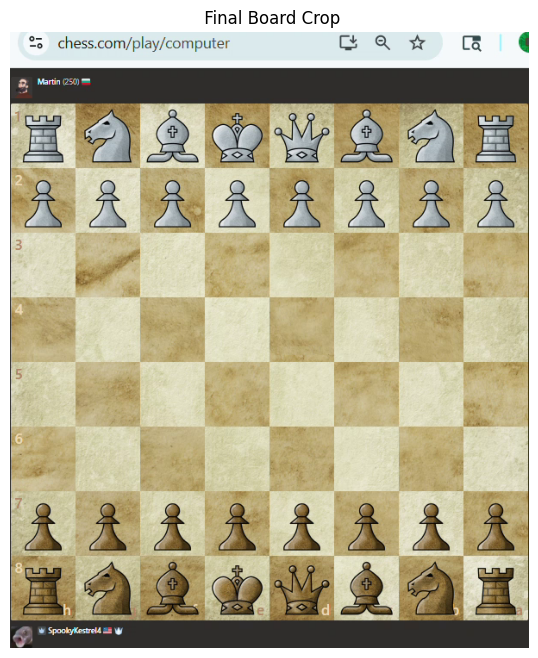

diff_score: 0.184303125
Piece movement started
diff_score: 0.3213609375
diff_score: 0.2768515625
diff_score: 0.32133125
diff_score: 0.34758125
diff_score: 0.4151390625
diff_score: 0.100353125
diff_score: 0.051709375
diff_score: 0.042453125
diff_score: 0.039584375
diff_score: 0.0397140625
Detected orientation: WHITE ON TOP / BLACK ON BOTTOM
Detected starting turn: WHITE
No reliable move candidate.
Best move: b2b4
Move score: 1.6210204081632653
Second score: 1.6193877551020408
Score gap: 0.0016326530612245094
Changed squares: ['b4', 'f4']
diff_score: 0.039465625
diff_score: 0.039821875
diff_score: 0.0394109375
diff_score: 0.0397140625
diff_score: 0.039465625
diff_score: 0.039821875
diff_score: 0.0394109375
diff_score: 0.0397140625
diff_score: 0.039465625
diff_score: 0.039821875
diff_score: 0.0394109375
diff_score: 0.0397140625
diff_score: 0.039465625
diff_score: 0.039821875
diff_score: 0.0394109375
diff_score: 0.0397140625
diff_score: 0.039465625
diff_score: 0.039821875
diff_score: 0.039

['e4', 'e5', 'f3', 'f6', 'b3', 'Be7', 'b4', 'd5']

In [94]:
play_and_track_2d_moves("videos/chess_recording_7.mp4")